# Above threshold optimization example

### Load dependencies and interfaces

In [1]:
import os
import time
from typing import Dict, List

import numpy as np
import pyro
import torch

import pyciemss
import pyciemss.visuals.plots as plots
from pyciemss.integration_utils.intervention_builder import (
    combine_static_parameter_interventions,
    param_value_objective,
    start_time_objective,
    start_time_param_value_objective,
    intervention_func_combinator,
)
from pyciemss.ouu.qoi import obs_max_qoi, obs_nday_average_qoi
from copy import deepcopy

smoke_test = "CI" in os.environ

### Select model

In [2]:
MODEL_PATH = "https://raw.githubusercontent.com/DARPA-ASKEM/simulation-integration/main/data/models/"
model_opt1 = os.path.join(MODEL_PATH, "SIR_stockflow.json")
model_opt2 = os.path.join(MODEL_PATH, "SEIRHD_NPI_Type1_petrinet.json")

### Set parameters for sampling

In [3]:
start_time = 0.0
end_time_SIR = 40.0
end_time_SEIRHD = 60.0
end_time_SEIRHD2 = 90.0
logging_step_size = 1.0
num_samples = 100
num_samples_ouu = 100 # controls accuracy of risk estimation in each optimization iteration
maxiter = 3    # maximum number of restarts of local convex optimizer leading to maxiter+1 local optimizations
maxfeval = 30  # maximum number of function evaluations in each instance of local convex optimization

### Baseline samples before optimization from model 1 (SIR)

Time taken:  0.6099967956542969
Risk associated with QoI: [473.92011718749995]


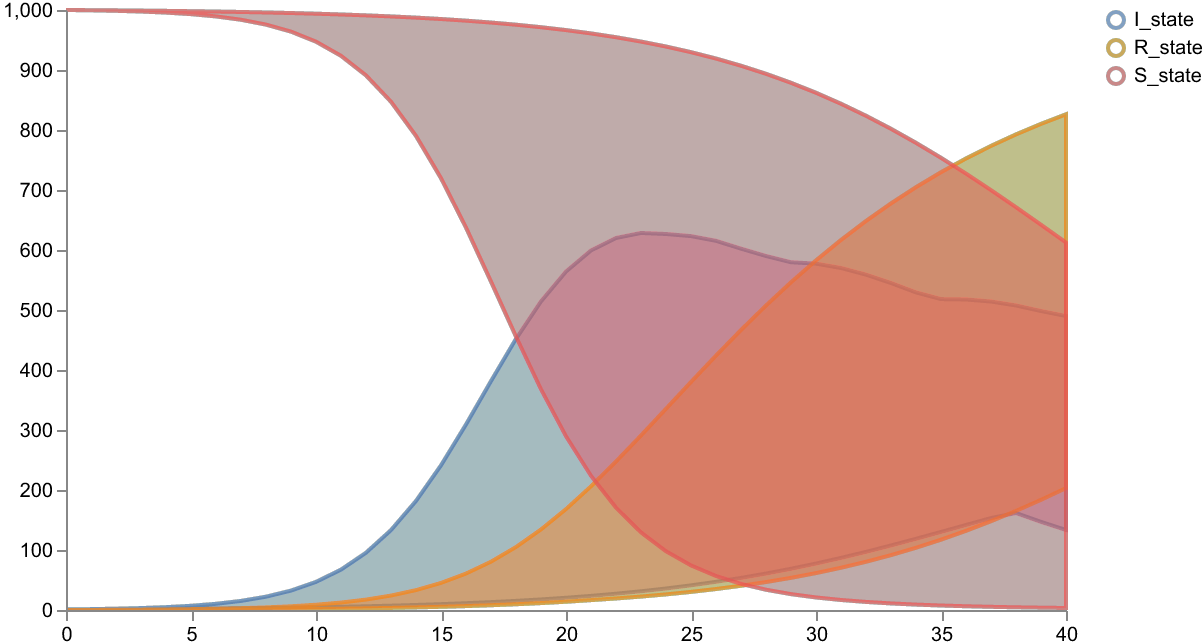

In [4]:
start_t = time.time()
sample_results1 = pyciemss.sample(
    model_opt1,
    end_time_SIR,
    logging_step_size,
    num_samples,
    start_time=start_time,
    solver_method="rk4",
    solver_options={"step_size": 1.},
)
print("Time taken: ", time.time()-start_t)
print("Risk associated with QoI:", sample_results1["risk"]["I_state"]["risk"])
# Plot results for all states
schema = plots.trajectories(sample_results1["data"], keep=".*_state", qlow=0.0, qhigh=1.0)
plots.ipy_display(schema, dpi=150)

## BELOW threshold optimization
Minimum change in the intervention parameter from the current value to get infections below 200 individuals at 40 days for SIR model

In [9]:
# Define optimization problem setup
observed_params = ["I_state"]
intervention_time = [torch.tensor(1.0)]
intervened_params = ["p_cbeta"]
p_cbeta_current = 0.35
initial_guess_interventions = 0.15
bounds_interventions = [[0.1], [0.5]]
static_parameter_interventions = param_value_objective(
    param_name = intervened_params,
    param_value = [lambda x: torch.tensor(x)],
    start_time = intervention_time,
)

risk_bound = 200.0
qoi = lambda y: obs_nday_average_qoi(y, observed_params, 1)
objfun = lambda x: np.abs(p_cbeta_current - x)

# Run optimize interface
opt_result1 = pyciemss.optimize(
    model_opt1,
    end_time_SIR,
    logging_step_size,
    qoi,
    risk_bound,
    static_parameter_interventions,
    objfun,
    initial_guess_interventions=initial_guess_interventions,
    bounds_interventions=bounds_interventions,
    start_time=start_time,
    n_samples_ouu=num_samples_ouu,
    maxiter=maxiter,
    maxfeval=maxfeval,
    solver_method="rk4",
    solver_options={"step_size": 1.},
)
print(f'Optimal policy:', opt_result1["policy"])
print(opt_result1)

Optimal policy: tensor([0.1955], dtype=torch.float64)
{'policy': tensor([0.1955], dtype=torch.float64), 'OptResults':                     message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 0.15453238378927586
                          x: [ 1.955e-01]
                        nit: 3
      minimization_failures: 0
                       nfev: 30
 lowest_optimization_result: message: Optimization terminated successfully.
                             success: True
                              status: 1
                                 fun: 0.15453238378927586
                                   x: [ 1.955e-01]
                                nfev: 7
                               maxcv: 0.0}


#### Sample using optimal policy as intervention

Intervention:  {1.0: {'p_cbeta': tensor([0.1955])}}
Risk associated with QoI: [215.73131103515624]


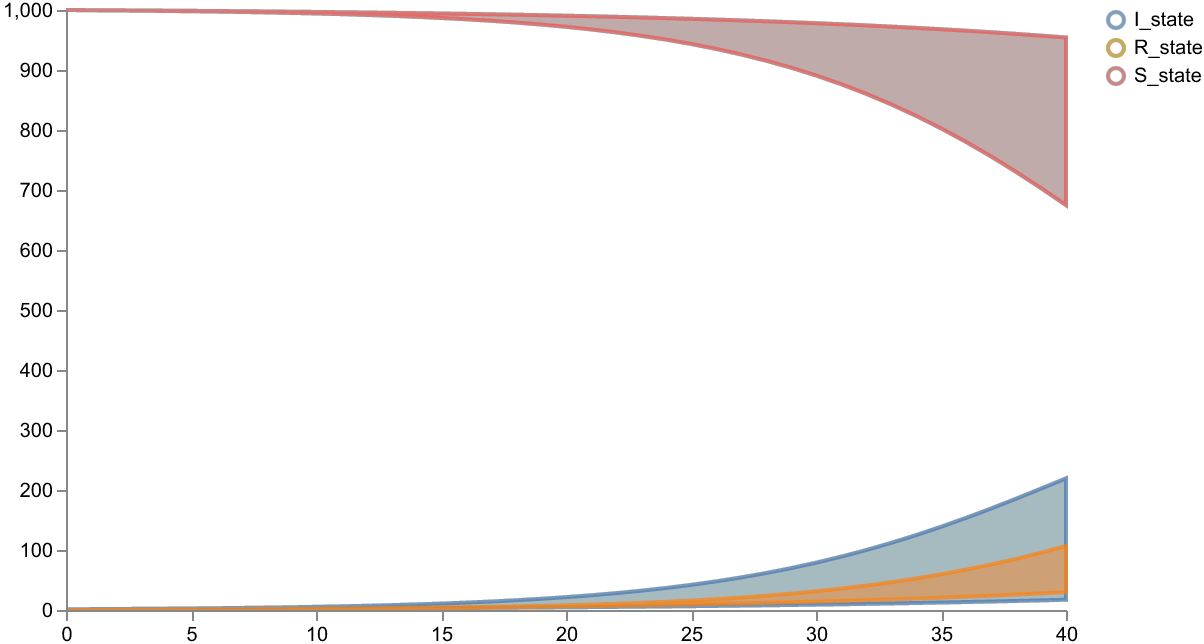

In [10]:
print("Intervention: ", static_parameter_interventions(opt_result1["policy"]))
result1 = pyciemss.sample(
    model_opt1,
    end_time_SIR,
    logging_step_size,
    num_samples,
    start_time=start_time,
    static_parameter_interventions=static_parameter_interventions(opt_result1["policy"]),
    solver_method="rk4",
    solver_options={"step_size": 1.},
)
# display(result1["data"])
print("Risk associated with QoI:", result1["risk"][observed_params[0]]["risk"])
# Plot results for all states
schema = plots.trajectories(result1["data"], keep=".*_state", qlow=0.0, qhigh=1.0)
plots.ipy_display(schema, dpi=150)

## ABOVE threshold optimization
Minimum change in the intervention parameter from the current value to keep infections above 200 individuals at 40 days for SIR model

In [7]:
# Define optimization problem setup
observed_params = ["I_state"]
intervention_time = [torch.tensor(1.0)]
intervened_params = ["p_cbeta"]
p_cbeta_current = 0.35
initial_guess_interventions = 0.15
bounds_interventions = [[0.1], [0.5]]
static_parameter_interventions = param_value_objective(
    param_name = intervened_params,
    param_value = [lambda x: torch.tensor(x)],
    start_time = intervention_time,
)

###### risk_bound and qui changed to negative here #######################
risk_bound = -200.0
qoi = lambda y: -obs_nday_average_qoi(y, observed_params, 1)
objfun = lambda x: np.abs(p_cbeta_current - x)

# Run optimize interface
opt_result1 = pyciemss.optimize(
    model_opt1,
    end_time_SIR,
    logging_step_size,
    qoi,
    risk_bound,
    static_parameter_interventions,
    objfun,
    initial_guess_interventions=initial_guess_interventions,
    bounds_interventions=bounds_interventions,
    start_time=start_time,
    n_samples_ouu=num_samples_ouu,
    maxiter=maxiter,
    maxfeval=maxfeval,
    solver_method="rk4",
    solver_options={"step_size": 1.},
)
print(f'Optimal policy:', opt_result1["policy"])
print(opt_result1)

Optimal policy: tensor([0.3500], dtype=torch.float64)
{'policy': tensor([0.3500], dtype=torch.float64), 'OptResults':                     message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 9.999999999898979e-06
                          x: [ 3.500e-01]
                        nit: 3
      minimization_failures: 0
                       nfev: 85
 lowest_optimization_result: message: Optimization terminated successfully.
                             success: True
                              status: 1
                                 fun: 9.999999999898979e-06
                                   x: [ 3.500e-01]
                                nfev: 19
                               maxcv: 0.0}


Intervention:  {1.0: {'p_cbeta': tensor([0.3500])}}
Risk associated with QoI: [427.720068359375]


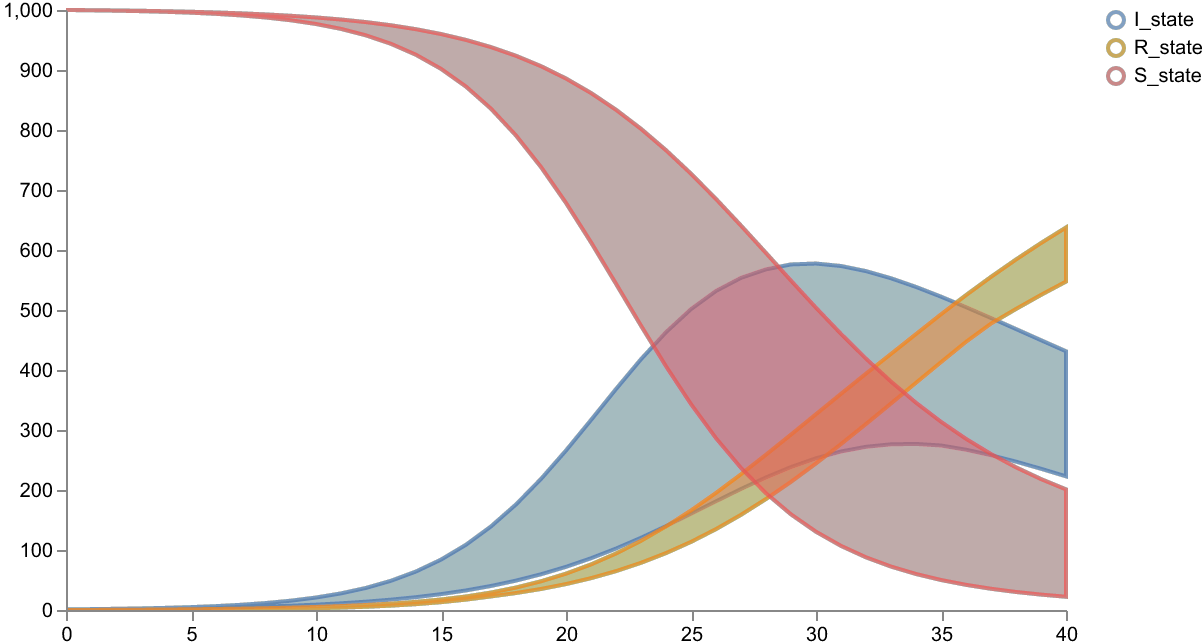

In [8]:
print("Intervention: ", static_parameter_interventions(opt_result1["policy"]))
result1 = pyciemss.sample(
    model_opt1,
    end_time_SIR,
    logging_step_size,
    num_samples,
    start_time=start_time,
    static_parameter_interventions=static_parameter_interventions(opt_result1["policy"]),
    solver_method="rk4",
    solver_options={"step_size": 1.},
)
# display(result1["data"])
print("Risk associated with QoI:", result1["risk"][observed_params[0]]["risk"])
# Plot results for all states
schema = plots.trajectories(result1["data"], keep=".*_state", qlow=0.0, qhigh=1.0)
plots.ipy_display(schema, dpi=150)